In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import StepLR
from neuralop.models import FNO
from neuralop.layers.channel_mlp import ChannelMLP
from neuralop.utils import count_model_params
import sys
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [21]:
# Input grid: C 코드와 같은 방식으로 생성
rows = 65
cols = 65
g = 2.0

# C 코드의 x, y: ghost/corner 포함 좌표 (길이 67)
i_x = torch.linspace(0, cols + 1, cols + 2, dtype=torch.float32)
i_y = torch.linspace(0, rows + 1, rows + 2, dtype=torch.float32)

x = 0.5 * (1 - torch.tanh(g * (1.0 - 2.0 * (i_x - 1.0) / (cols - 1))) / np.tanh(g))
y = 0.5 * (1 - torch.tanh(g * (1.0 - 2.0 * (i_y - 1.0) / (rows - 1))) / np.tanh(g))

# C 코드의 xc, yc: cell center 좌표 (길이 66)
xc = 0.5 * (x[:-1] + x[1:])
yc = 0.5 * (y[:-1] + y[1:])

# 모델 입력은 65x65 격자를 쓰도록 cell center 중 앞의 65개 사용
x_model = xc[:cols]
y_model = yc[:rows]
t = torch.linspace(5, 10, 51)

X, Y, T = torch.meshgrid(x_model, y_model, t, indexing='ij')
grid_tensor = torch.stack([X, Y, T], dim=-1)
input_tensor = grid_tensor.unsqueeze(0)

print(f'x shape: {x.shape}, xc shape: {xc.shape}')
print(f'y shape: {y.shape}, yc shape: {yc.shape}')
print(f'model grid shape: {grid_tensor.shape}')

input_tensor_permuted = input_tensor.permute(0, 4, 1, 2, 3).to(DEVICE)
print(f'최종 Input 텐서의 형태 (Shape): {input_tensor_permuted.shape}')

x shape: torch.Size([67]), xc shape: torch.Size([66])
y shape: torch.Size([67]), yc shape: torch.Size([66])
model grid shape: torch.Size([65, 65, 51, 3])
최종 Input 텐서의 형태 (Shape): torch.Size([1, 3, 65, 65, 51])


In [10]:
# initial values
rows, cols = 65, 65

u = np.fromfile('/home/seongwon/cavity/data_re500/u_50000.bin', dtype=np.float64).reshape(rows + 1, cols)
v = np.fromfile('/home/seongwon/cavity/data_re500/v_50000.bin', dtype=np.float64).reshape(rows, cols + 1)
p = np.fromfile('/home/seongwon/cavity/data_re500/p_50000.bin', dtype=np.float64).reshape(rows + 1, cols + 1)


gamma = (x[1:-1] - xc[0:-1])/(xc[1:]-xc[0:-1])
gamma = np.tile(gamma.reshape(-1, 1), (1, cols))
delta = (y[1:-1] - yc[0:-1])/(yc[1:]-yc[0:-1])
delta = np.tile(delta.reshape(-1, 1), (1, rows))
u_new = delta * u[1:, :]+(1 - delta) * u[:-1, :]
v_new = gamma * v[:, 1:]+(1 - gamma) * v[:, :-1]
p_new = 1/4 * (p[:-1, :-1] + p[1:, :-1] + p[:-1, 1:] + p[1:, 1:])

u_tensor = torch.from_numpy(u_new.T).float().to(DEVICE)
v_tensor = torch.from_numpy(v_new.T).float().to(DEVICE)
p_tensor = torch.from_numpy(p_new.T).float().to(DEVICE)


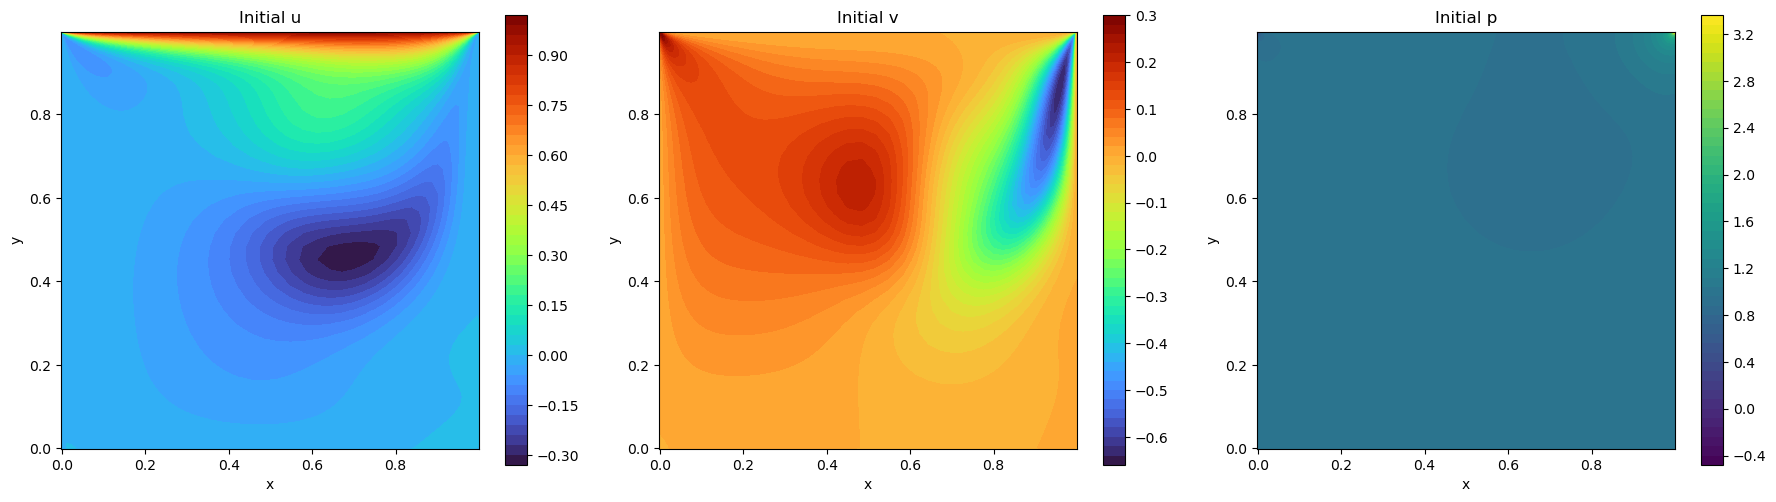

In [11]:
# initial condition 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_plot = X[:, :, 0].cpu()
y_plot = Y[:, :, 0].cpu()

im0 = axes[0].contourf(x_plot, y_plot, u_tensor.cpu(), levels=50, cmap='turbo')
axes[0].set_title('Initial u')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(x_plot, y_plot, v_tensor.cpu(), levels=50, cmap='turbo')
axes[1].set_title('Initial v')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(x_plot, y_plot, p_tensor.cpu(), levels=50, cmap='viridis')
axes[2].set_title('Initial p')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [5]:
# model configuration
hidden_channels = 128
model = FNO(
    n_modes = (8,8,8),
    in_channels=3,
    out_channels=3,
    hidden_channels=hidden_channels,
).to(DEVICE)

# Count and display the number of parameters
n_params = count_model_params(model) # 모델의 파라미터 수를 계산
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush() # 버퍼에 있는 내용을 강제로 출력하게 하는 함수임.


Our model has 42144387 parameters.


In [13]:
# creating the optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scheduler = StepLR(optimizer, step_size=5000, gamma=0.5)

NameError: name 'model' is not defined

In [12]:
# Setting up the loss functions
def lid_cavity_loss(pred_tensor, initial_condition, Re=500.0, dx=x_model, dy=y_model, dt=t):
    """
    pred_tensor shape: (Batch, Channels, X, Y, T) -> (1, 3, 65, 65, 51)
    Channels: 0 -> u (x방향 속도), 1 -> v (y방향 속도), 2 -> p (압력)
    """
    # 1. 속도 및 압력장 분리
    u = pred_tensor[:, 0, ...]
    v = pred_tensor[:, 1, ...]
    p = pred_tensor[:, 2, ...]
    nu = 1.0 / Re

    # spacing 타입/디바이스 통일
    dx_t = dx.to(device=u.device, dtype=u.dtype) if torch.is_tensor(dx) else dx
    dy_t = dy.to(device=u.device, dtype=u.dtype) if torch.is_tensor(dy) else dy
    dt_t = dt.to(device=u.device, dtype=u.dtype) if torch.is_tensor(dt) else dt
    spacing = (dx_t, dy_t, dt_t)

    # 2. 미분 계산 (dim=(1,2,3) -> X,Y,T)
    du_dx, du_dy, du_dt = torch.gradient(u, spacing=spacing, dim=(1, 2, 3))
    dv_dx, dv_dy, dv_dt = torch.gradient(v, spacing=spacing, dim=(1, 2, 3))
    dp_dx, dp_dy, _ = torch.gradient(p, spacing=spacing, dim=(1, 2, 3))

    # 2차 미분 (확산항, Laplacian)
    d2u_dx2, _, _ = torch.gradient(du_dx, spacing=spacing, dim=(1, 2, 3))
    _, d2u_dy2, _ = torch.gradient(du_dy, spacing=spacing, dim=(1, 2, 3))
    d2v_dx2, _, _ = torch.gradient(dv_dx, spacing=spacing, dim=(1, 2, 3))
    _, d2v_dy2, _ = torch.gradient(dv_dy, spacing=spacing, dim=(1, 2, 3))

    # 3. PDE Loss (Navier-Stokes 잔차)
    momentum_x = du_dt + u * du_dx + v * du_dy + dp_dx - nu * (d2u_dx2 + d2u_dy2)
    momentum_y = dv_dt + u * dv_dx + v * dv_dy + dp_dy - nu * (d2v_dx2 + d2v_dy2)
    continuity = du_dx + dv_dy
    loss_pde = torch.mean(momentum_x**2) + torch.mean(momentum_y**2) + torch.mean(continuity**2)

    # 4. 경계 조건 Loss
    loss_bc_top = torch.mean((u[:, :, -1, :] - 1.0)**2) + torch.mean((v[:, :, -1, :] - 0.0)**2)
    loss_bc_bottom = torch.mean((u[:, :, 0, :] - 0.0)**2) + torch.mean((v[:, :, 0, :] - 0.0)**2)
    loss_bc_left = torch.mean((u[:, 0, :, :] - 0.0)**2) + torch.mean((v[:, 0, :, :] - 0.0)**2)
    loss_bc_right = torch.mean((u[:, -1, :, :] - 0.0)**2) + torch.mean((v[:, -1, :, :] - 0.0)**2)
    loss_bc = loss_bc_top + loss_bc_bottom + loss_bc_left + loss_bc_right

    # 5. 초기 조건 Loss
    u_initial_pred = u[:, :, :, 0]
    v_initial_pred = v[:, :, :, 0]
    p_initial_pred = p[:, :, :, 0]
    loss_ic = (
        torch.mean((u_initial_pred - initial_condition[0])**2)
        + torch.mean((v_initial_pred - initial_condition[1])**2)
        + torch.mean((p_initial_pred - initial_condition[2])**2)
    )

    # 6. 최종 Loss
    total_loss = loss_pde + loss_bc + loss_ic
    return total_loss

In [8]:
num_iterations = 10000

model.train()
for step in range(num_iterations):
    optimizer.zero_grad()

    # 모델 예측
    pred = model(input_tensor_permuted.float())

    # Loss 계산
    loss = lid_cavity_loss(
        pred,
        initial_condition=(u_tensor, v_tensor, p_tensor),
        dx=x_model,
        dy=y_model,
        dt=t,
    )

    # Backpropagation
    loss.backward()
    optimizer.step()
    scheduler.step()

    if (step + 1) % 100 == 0 or step == 0:
        print(f"Step {step+1}/{num_iterations}, Loss: {loss.item():.6f}")

os.makedirs('./model', exist_ok=True)
torch.save(model.state_dict(), f'./model/cavity_pino_hl{hidden_channels}.pth')

Step 1/10000, Loss: 2.206508
Step 100/10000, Loss: 0.251621
Step 200/10000, Loss: 0.157606
Step 300/10000, Loss: 0.126669
Step 400/10000, Loss: 0.111166
Step 500/10000, Loss: 0.109355
Step 600/10000, Loss: 0.095351
Step 700/10000, Loss: 0.093612
Step 800/10000, Loss: 0.085420
Step 900/10000, Loss: 0.088572
Step 1000/10000, Loss: 0.079396
Step 1100/10000, Loss: 0.075465
Step 1200/10000, Loss: 0.086346
Step 1300/10000, Loss: 0.071018
Step 1400/10000, Loss: 0.068643
Step 1500/10000, Loss: 0.069237
Step 1600/10000, Loss: 0.072236
Step 1700/10000, Loss: 0.065718
Step 1800/10000, Loss: 0.098227
Step 1900/10000, Loss: 0.062893
Step 2000/10000, Loss: 0.062859
Step 2100/10000, Loss: 0.061470
Step 2200/10000, Loss: 0.059779
Step 2300/10000, Loss: 0.062733
Step 2400/10000, Loss: 0.087141
Step 2500/10000, Loss: 0.057784
Step 2600/10000, Loss: 0.057150
Step 2700/10000, Loss: 0.063784
Step 2800/10000, Loss: 0.079415
Step 2900/10000, Loss: 0.055081
Step 3000/10000, Loss: 0.058758
Step 3100/10000, Los

In [ ]:
# 모델 로드
hidden_channels = 128
model = FNO(
    n_modes=(8, 8, 8),
    in_channels=3,
    out_channels=3,
    hidden_channels=hidden_channels,
).to(DEVICE)

state_path = '/home/seongwon/AI/PINO/model/cavity_pino_hl128.pth'
state_dict = torch.load(state_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(state_dict)
model.eval()

FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([128, 128, 8, 8, 5]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(128, 128, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(128, 64, kernel_size=(1,), stride=(1,))
          (1): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(6, 256, kernel_size=(1,), stride=(1,))
      (1): Conv1d(256, 128, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(128, 256, kernel_size=(1,), stride=(1,))
      (1): Conv1d(256, 3,

In [ ]:
# 예측 (모델/입력 디바이스 일치)
model.eval()
with torch.no_grad():
    pred = model(input_tensor_permuted.to(DEVICE).float())
pred = pred.cpu()

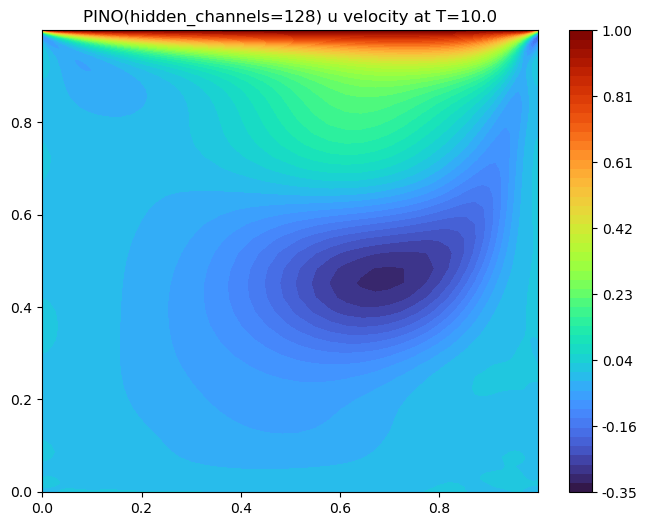

In [35]:
# u velocity at the final time step (T=10.0)
plt.figure(figsize=(8, 6))

vmin, vmax = -0.35, 1.0
levels = np.linspace(vmin, vmax, 51)
ticks = np.linspace(vmin, vmax, 8)

u_plot = np.clip(pred[0, 0, :, :, 0], vmin, vmax)
cf = plt.contourf(
    X[:, :, 0], Y[:, :, 0], u_plot,
    levels=levels, cmap='turbo', vmin=vmin, vmax=vmax
  )
cbar = plt.colorbar(cf, ticks=ticks)
cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])

plt.title('PINO(hidden_channels=128) u velocity at T=10.0')
plt.show()

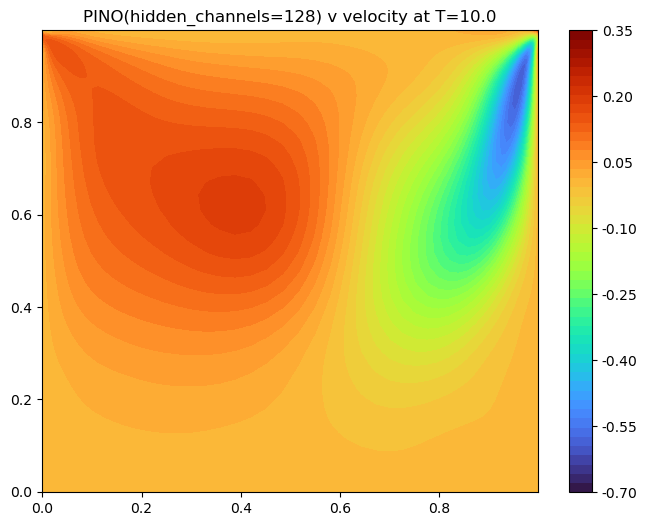

In [32]:
# v velocity at the final time step (T=10.0)
plt.figure(figsize=(8, 6))

vmin, vmax = -0.7, 0.35
levels = np.linspace(vmin, vmax, 51)
ticks = np.linspace(vmin, vmax, 8)

v_plot = np.clip(pred[0, 1, :, :, -1], vmin, vmax)
cf = plt.contourf(
    X[:, :, 0], Y[:, :, 0], v_plot,
    levels=levels, cmap='turbo', vmin=vmin, vmax=vmax
  )
cbar = plt.colorbar(cf, ticks=ticks)
cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])

plt.title('PINO(hidden_channels=128) v velocity at T=10.0')
plt.show()